# Notebook 09 — CLAHE Ablation Study

**Mục tiêu:** So sánh hiệu năng có/không CLAHE preprocessing trên tất cả 7 models.

**Models:** Linear Probe · Partial FT v1/v2 · Full FT v1/v2 · ViT-Small · ResNet50

**Strategy:** Load existing predictions (no-CLAHE) từ CSV → chỉ chạy CLAHE inference mới → compare.

**Input cần add:**
- Output NB01 → `rsna_test.csv`
- Output NB04 v1 → checkpoints Partial v1, Full v1, Linear Probe
- Output NB04 v3 → checkpoints Partial v2, Full v2
- Output NB04/05 → prediction CSVs (no-CLAHE baseline)
- Output NB04b → `ijepa_full_finetune_resume_best.pth`
- Output NB02 → ResNet50 + ViT checkpoints
- RSNA dataset → ảnh DICOM

In [1]:
# ============================================================
# CELL 1: IMPORTS + CONFIG
# ============================================================
import os, gc, json, math, time, shutil, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tvm

try:
    import timm
except ImportError:
    import subprocess; subprocess.run(["pip","install","-q","timm"])
    import timm

try:
    import pydicom
except ImportError:
    import subprocess; subprocess.run(["pip","install","-q","pydicom"])
    import pydicom

try:
    import cv2
except ImportError:
    import subprocess; subprocess.run(["pip","install","-q","opencv-python-headless"])
    import cv2

from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score, confusion_matrix

SEED = 42
import random
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

OUTPUT_DIR = Path("/kaggle/working/notebook09_clahe_ablation")
TABLE_DIR  = OUTPUT_DIR / "tables"
FIG_DIR    = OUTPUT_DIR / "figures"
for d in [TABLE_DIR, FIG_DIR]: d.mkdir(parents=True, exist_ok=True)

INPUT_ROOT   = Path("/kaggle/input")
WORKING_ROOT = Path("/kaggle/working")
IMG_SIZE     = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# CLAHE params — standard for chest X-ray
CLAHE_CLIP  = 2.0
CLAHE_GRID  = (8, 8)

SESSION_SAFE_SECONDS = 11.0 * 3600
NOTEBOOK_START       = time.time()
print("Output:", OUTPUT_DIR)

Device: cuda
GPU: Tesla T4
Output: /kaggle/working/notebook09_clahe_ablation


In [2]:
# ============================================================
# CELL 2: TÌM INPUT FILES
# ============================================================
def find_file(name):
    for root in [WORKING_ROOT, INPUT_ROOT]:
        for p in root.rglob(name):
            return p
    return None

# ── RSNA metadata ────────────────────────────────────────
RSNA_TEST_CSV = find_file("rsna_test.csv")
RSNA_TRAIN_CSV = find_file("rsna_train.csv")

# ── Checkpoints ──────────────────────────────────────────
CKPT = {
    "I-JEPA Linear Probe":    find_file("ijepa_linear_probe_best.pth"),
    "I-JEPA Partial FT v1":   find_file("ijepa_partial_finetune_best.pth"),
    "I-JEPA Partial FT v2":   find_file("ijepa_partial_finetune_v2_best.pth"),
    "I-JEPA Full FT v1":      find_file("ijepa_full_finetune_resume_best.pth"),
    "I-JEPA Full FT v2":      find_file("ijepa_full_finetune_v2_best.pth"),
    "ResNet50 ImageNet":       find_file("resnet50_imagenet_best.pth"),
    "ViT-Small ImageNet":      find_file("vit_imagenet_best.pth"),
}

# ── Existing predictions (no-CLAHE baseline) ─────────────
PRED_CSV = {
    "I-JEPA Linear Probe":    find_file("ijepa_linear_probe_predictions.csv"),
    "I-JEPA Partial FT v1":   find_file("ijepa_partial_finetune_predictions.csv"),
    "I-JEPA Partial FT v2":   find_file("ijepa_partial_finetune_v2_predictions.csv"),
    "I-JEPA Full FT v1":      find_file("ijepa_full_ft_resume_predictions.csv"),
    "I-JEPA Full FT v2":      find_file("ijepa_full_finetune_v2_predictions.csv"),
    "ResNet50 ImageNet":       find_file("resnet50_predictions.csv"),
    "ViT-Small ImageNet":      find_file("vit_predictions.csv"),
}

print("=== Checkpoints ===")
for k, v in CKPT.items():
    print(f"  {'✓' if v else '✗':2s} {k}")

print("\n=== Prediction CSVs (no-CLAHE baseline) ===")
for k, v in PRED_CSV.items():
    print(f"  {'✓' if v else '○':2s} {k}  {'← will generate' if not v else ''}")

assert RSNA_TEST_CSV, "Thiếu rsna_test.csv"
print("\nRSNA test CSV:", RSNA_TEST_CSV)

=== Checkpoints ===
  ✓  I-JEPA Linear Probe
  ✓  I-JEPA Partial FT v1
  ✓  I-JEPA Partial FT v2
  ✓  I-JEPA Full FT v1
  ✓  I-JEPA Full FT v2
  ✓  ResNet50 ImageNet
  ✓  ViT-Small ImageNet

=== Prediction CSVs (no-CLAHE baseline) ===
  ✓  I-JEPA Linear Probe  
  ✓  I-JEPA Partial FT v1  
  ✓  I-JEPA Partial FT v2  
  ○  I-JEPA Full FT v1  ← will generate
  ✓  I-JEPA Full FT v2  
  ✓  ResNet50 ImageNet  
  ✓  ViT-Small ImageNet  

RSNA test CSV: /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/rsna_test.csv


In [3]:
# ============================================================
# CELL 3: UTILITY FUNCTIONS
# ============================================================

# ── Path fix ──────────────────────────────────────────────
def fix_df_paths(df):
    def _fix(p):
        if Path(p).exists(): return p
        m = list(INPUT_ROOT.rglob(Path(p).name))
        return str(m[0]) if m else None
    df = df.copy()
    df["image_path"] = df["image_path"].apply(_fix)
    return df.dropna(subset=["image_path"]).reset_index(drop=True)

# ── CLAHE helper ──────────────────────────────────────────
_clahe_obj = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)

def apply_clahe(gray_uint8: np.ndarray) -> np.ndarray:
    """Input: uint8 grayscale [H,W]. Output: uint8 CLAHE-enhanced [H,W]."""
    return _clahe_obj.apply(gray_uint8)

# ── Read image — với và không CLAHE ──────────────────────
def read_image(path, use_clahe=False):
    p = str(path)
    if p.endswith(".dcm"):
        arr = pydicom.dcmread(p).pixel_array.astype(np.float32)
        # MONOCHROME1 fix
        ds = pydicom.dcmread(p)
        if getattr(ds, "PhotometricInterpretation","") == "MONOCHROME1":
            arr = arr.max() - arr
        mn, mx = arr.min(), arr.max()
        arr = ((arr - mn) / (mx - mn + 1e-8) * 255).astype(np.uint8)
    else:
        arr = np.array(Image.open(p).convert("L"))
    if use_clahe:
        arr = apply_clahe(arr)
    return Image.fromarray(arr).convert("RGB")

# ── Transforms ─────────────────────────────────────────
def make_eval_transform():
    return T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

# ── Dataset ────────────────────────────────────────────
class RSNADataset(Dataset):
    def __init__(self, df, use_clahe=False, transform=None):
        self.df         = df.reset_index(drop=True)
        self.use_clahe  = use_clahe
        self.transform  = transform or make_eval_transform()
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = read_image(row["image_path"], use_clahe=self.use_clahe)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(float(row["label"]), dtype=torch.float32)

# ── Metrics ─────────────────────────────────────────────
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    try:    auc = roc_auc_score(y_true, y_prob)
    except: auc = np.nan
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return {
        "auc":              float(auc),
        "f1":               float(f1_score(y_true, y_pred, zero_division=0)),
        "recall_pneumonia": float(recall_score(y_true, y_pred, zero_division=0)),
        "precision":        float(precision_score(y_true, y_pred, zero_division=0)),
        "specificity":      float(tn / (tn + fp + 1e-8)),
    }

print("Utilities ready ✓")
print(f"CLAHE: clipLimit={CLAHE_CLIP}, tileGridSize={CLAHE_GRID}")

Utilities ready ✓
CLAHE: clipLimit=2.0, tileGridSize=(8, 8)


In [4]:
# ============================================================
# CELL 4: LOAD TEST DATA + POS_WEIGHT
# ============================================================
test_df  = fix_df_paths(pd.read_csv(RSNA_TEST_CSV))

# POS_WEIGHT từ train set nếu có, fallback hardcode
if RSNA_TRAIN_CSV:
    train_df = fix_df_paths(pd.read_csv(RSNA_TRAIN_CSV))
    n_neg = (train_df["label"]==0).sum()
    n_pos = (train_df["label"]==1).sum()
    POS_WEIGHT = torch.tensor([n_neg/n_pos], dtype=torch.float32).to(DEVICE)
else:
    POS_WEIGHT = torch.tensor([3.439], dtype=torch.float32).to(DEVICE)  # fallback

print(f"Test: {len(test_df):,} samples | "
      f"pos={test_df['label'].sum()} ({test_df['label'].mean()*100:.1f}%)")
print(f"POS_WEIGHT = {POS_WEIGHT.item():.4f}")

# Verify CLAHE effect on 1 sample
_sample_path = test_df["image_path"].iloc[0]
img_raw   = read_image(_sample_path, use_clahe=False)
img_clahe = read_image(_sample_path, use_clahe=True)
arr_raw   = np.array(img_raw.convert("L"))
arr_clahe = np.array(img_clahe.convert("L"))
print(f"\nCLAHE effect on sample image:")
print(f"  No CLAHE: mean={arr_raw.mean():.1f}, std={arr_raw.std():.1f}")
print(f"  CLAHE:    mean={arr_clahe.mean():.1f}, std={arr_clahe.std():.1f}")
print(f"  Pixel diff: {np.abs(arr_raw.astype(int)-arr_clahe.astype(int)).mean():.2f} avg")

Test: 4,003 samples | pos=902 (22.5%)
POS_WEIGHT = 3.4387

CLAHE effect on sample image:
  No CLAHE: mean=145.8, std=70.3
  CLAHE:    mean=145.5, std=68.5
  Pixel diff: 14.80 avg


In [5]:
# ============================================================
# CELL 5: MODEL LOADERS
# ============================================================

class IJEPAClassifier(nn.Module):
    def __init__(self, encoder, embed_dim=384, dropout=0.1):
        super().__init__()
        self.encoder    = encoder
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim), nn.Dropout(dropout), nn.Linear(embed_dim, 1)
        )
    def forward(self, x):
        return self.classifier(self.encoder(x)).squeeze(-1)

def load_ijepa(ckpt_path, dropout=0.1):
    enc = timm.create_model("vit_small_patch16_224", pretrained=False, num_classes=0)
    model = IJEPAClassifier(enc, embed_dim=enc.num_features, dropout=dropout)
    try:    ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    except: ck = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ck["model_state_dict"], strict=False)
    return model.to(DEVICE)

def load_resnet50(ckpt_path):
    model = tvm.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 1)
    try:    ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    except: ck = torch.load(ckpt_path, map_location=DEVICE)
    sd = ck.get("model_state_dict", ck)
    model.load_state_dict(sd, strict=False)
    return model.to(DEVICE)

def load_vit(ckpt_path):
    model = timm.create_model("vit_small_patch16_224", pretrained=False, num_classes=1)
    try:    ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    except: ck = torch.load(ckpt_path, map_location=DEVICE)
    sd = ck.get("model_state_dict", ck)
    model.load_state_dict(sd, strict=False)
    return model.to(DEVICE)

# Map model name → loader function + dropout (for IJEPA)
MODEL_LOADERS = {
    "I-JEPA Linear Probe":  (load_ijepa,    {"dropout": 0.2}),
    "I-JEPA Partial FT v1": (load_ijepa,    {"dropout": 0.2}),
    "I-JEPA Partial FT v2": (load_ijepa,    {"dropout": 0.1}),
    "I-JEPA Full FT v1":    (load_ijepa,    {"dropout": 0.2}),
    "I-JEPA Full FT v2":    (load_ijepa,    {"dropout": 0.1}),
    "ResNet50 ImageNet":    (load_resnet50, {}),
    "ViT-Small ImageNet":   (load_vit,      {}),
}

print("Model loaders ready ✓")

Model loaders ready ✓


In [6]:
# ============================================================
# CELL 6: LOAD NO-CLAHE BASELINE TỪ CSV HOẶC GENERATE
# ============================================================
baseline_preds = {}   # model_name → DataFrame(label, prob_pneumonia)

for model_name, csv_path in PRED_CSV.items():
    if csv_path:
        df = pd.read_csv(csv_path)
        df["label"]          = df["label"].astype(int)
        df["prob_pneumonia"] = df["prob_pneumonia"].astype(float)
        baseline_preds[model_name] = df
        auc = roc_auc_score(df["label"], df["prob_pneumonia"])
        print(f"  ✓ {model_name}: loaded {len(df):,} | AUC={auc:.4f}")
    else:
        print(f"  ○ {model_name}: CSV not found — will generate from checkpoint")

# Generate from checkpoint nếu thiếu CSV
@torch.no_grad()
def run_inference(model, df, use_clahe=False, desc="infer"):
    model.eval()
    loader = DataLoader(RSNADataset(df, use_clahe=use_clahe),
                        batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
    all_probs, all_labels = [], []
    for imgs, labels in tqdm(loader, desc=desc, leave=False):
        imgs = imgs.to(DEVICE)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            logits = model(imgs)
        logits = logits.squeeze(-1) if logits.dim() > 1 else logits
        all_probs.extend(torch.sigmoid(logits).cpu().numpy())
        all_labels.extend(labels.numpy())
    return pd.DataFrame({"label": [int(l) for l in all_labels],
                         "prob_pneumonia": all_probs})

for model_name in PRED_CSV:
    if model_name in baseline_preds:
        continue
    ckpt = CKPT.get(model_name)
    if not ckpt:
        print(f"  ✗ {model_name}: no checkpoint — skip")
        continue
    if time.time() - NOTEBOOK_START > SESSION_SAFE_SECONDS:
        print("⏱  Time guard. Stop."); break

    loader_fn, kwargs = MODEL_LOADERS[model_name]
    model = loader_fn(ckpt, **kwargs)
    pred_df = run_inference(model, test_df, use_clahe=False, desc=f"{model_name} (no-CLAHE)")
    auc = roc_auc_score(pred_df["label"], pred_df["prob_pneumonia"])
    baseline_preds[model_name] = pred_df
    pred_df.to_csv(OUTPUT_DIR / f"{model_name.lower().replace(' ','_')}_no_clahe.csv", index=False)
    print(f"  ✓ {model_name}: generated | AUC={auc:.4f}")
    del model; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print(f"\nBaseline (no-CLAHE): {len(baseline_preds)} models loaded")

  ✓ I-JEPA Linear Probe: loaded 4,003 | AUC=0.7737
  ✓ I-JEPA Partial FT v1: loaded 4,003 | AUC=0.8003
  ✓ I-JEPA Partial FT v2: loaded 4,003 | AUC=0.8011
  ○ I-JEPA Full FT v1: CSV not found — will generate from checkpoint
  ✓ I-JEPA Full FT v2: loaded 4,003 | AUC=0.8041
  ✓ ResNet50 ImageNet: loaded 4,003 | AUC=0.8862
  ✓ ViT-Small ImageNet: loaded 4,003 | AUC=0.8797


I-JEPA Full FT v1 (no-CLAHE):   0%|          | 0/251 [00:00<?, ?it/s]

  ✓ I-JEPA Full FT v1: generated | AUC=0.8297

Baseline (no-CLAHE): 7 models loaded


In [7]:
# ============================================================
# CELL 7: CHẠY CLAHE INFERENCE CHO TẤT CẢ MODELS
# ============================================================
clahe_preds = {}

for model_name, ckpt in CKPT.items():
    if time.time() - NOTEBOOK_START > SESSION_SAFE_SECONDS:
        print(f"⏱  Time guard trước {model_name}. Dừng."); break

    if not ckpt:
        print(f"  ✗ {model_name}: no checkpoint — skip")
        continue
    if model_name not in baseline_preds:
        print(f"  ○ {model_name}: no baseline — skip CLAHE too")
        continue

    print(f"  Running CLAHE: {model_name}")
    loader_fn, kwargs = MODEL_LOADERS[model_name]
    model = loader_fn(ckpt, **kwargs)

    pred_df = run_inference(model, test_df, use_clahe=True,
                             desc=f"{model_name} (CLAHE)")
    auc = roc_auc_score(pred_df["label"], pred_df["prob_pneumonia"])
    clahe_preds[model_name] = pred_df
    pred_df.to_csv(OUTPUT_DIR / f"{model_name.lower().replace(' ','_')}_clahe.csv", index=False)
    print(f"    AUC={auc:.4f}")

    del model; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print(f"\nCLAHE inference: {len(clahe_preds)} models done")

  Running CLAHE: I-JEPA Linear Probe


I-JEPA Linear Probe (CLAHE):   0%|          | 0/251 [00:00<?, ?it/s]

    AUC=0.7048
  Running CLAHE: I-JEPA Partial FT v1


I-JEPA Partial FT v1 (CLAHE):   0%|          | 0/251 [00:00<?, ?it/s]

    AUC=0.7442
  Running CLAHE: I-JEPA Partial FT v2


...

    AUC=0.7517
  Running CLAHE: ResNet50 ImageNet


ResNet50 ImageNet (CLAHE):   0%|          | 0/251 [00:00<?, ?it/s]

    AUC=0.8640
  Running CLAHE: ViT-Small ImageNet


ViT-Small ImageNet (CLAHE):   0%|          | 0/251 [00:00<?, ?it/s]

    AUC=0.8646

CLAHE inference: 7 models done


In [8]:
# ============================================================
# CELL 8: TỔNG HỢP KẾT QUẢ + BẢNG SO SÁNH
# ============================================================
MODEL_ORDER = [
    "I-JEPA Linear Probe",
    "I-JEPA Partial FT v1", "I-JEPA Partial FT v2",
    "I-JEPA Full FT v1",    "I-JEPA Full FT v2",
    "ResNet50 ImageNet",    "ViT-Small ImageNet",
]

rows = []
for model_name in MODEL_ORDER:
    base_df  = baseline_preds.get(model_name)
    clahe_df = clahe_preds.get(model_name)

    if base_df is None and clahe_df is None:
        continue

    row = {"model": model_name}

    if base_df is not None:
        m_base = compute_metrics(base_df["label"], base_df["prob_pneumonia"])
        row.update({f"no_clahe_{k}": v for k, v in m_base.items()})
    else:
        m_base = None

    if clahe_df is not None:
        m_clahe = compute_metrics(clahe_df["label"], clahe_df["prob_pneumonia"])
        row.update({f"clahe_{k}": v for k, v in m_clahe.items()})
    else:
        m_clahe = None

    if m_base and m_clahe:
        row["delta_auc"]    = round(m_clahe["auc"]              - m_base["auc"],              4)
        row["delta_f1"]     = round(m_clahe["f1"]               - m_base["f1"],               4)
        row["delta_recall"] = round(m_clahe["recall_pneumonia"]  - m_base["recall_pneumonia"], 4)

    rows.append(row)

results_df = pd.DataFrame(rows)
results_df.to_csv(TABLE_DIR / "clahe_ablation_full.csv", index=False)

# Bảng tóm tắt để display
cols_show = ["model",
             "no_clahe_auc", "clahe_auc",    "delta_auc",
             "no_clahe_f1",  "clahe_f1",     "delta_f1",
             "no_clahe_recall_pneumonia", "clahe_recall_pneumonia", "delta_recall"]
summary_df = results_df[[c for c in cols_show if c in results_df.columns]].round(4)
summary_df.to_csv(TABLE_DIR / "clahe_ablation_summary.csv", index=False)

print("=== CLAHE Ablation Summary ===")
display(summary_df)

=== CLAHE Ablation Summary ===


,model,no_clahe_auc,clahe_auc,delta_auc,no_clahe_f1,clahe_f1,delta_f1,no_clahe_recall_pneumonia,clahe_recall_pneumonia,delta_recall
0,I-JEPA Linear Probe,0.7737,0.7048,-0.0689,0.5324,0.3499,-0.1825,0.6918,0.2849,-0.4069
1,I-JEPA Partial FT v1,0.8003,0.7442,-0.0562,0.5550,0.4924,-0.0625,0.7417,0.5599,-0.1818
2,I-JEPA Partial FT v2,0.8011,0.7419,-0.0592,0.5525,0.4869,-0.0656,0.7029,0.5554,-0.1475
3,I-JEPA Full FT v1,0.8297,0.7781,-0.0516,0.5752,0.5218,-0.0534,0.7738,0.7816,0.0078
4,I-JEPA Full FT v2,0.8041,0.7517,-0.0525,0.5552,0.4866,-0.0686,0.7195,0.5521,-0.1674
5,ResNet50 ImageNet,0.8862,0.8640,-0.0222,0.6249,0.4701,-0.1548,0.5421,0.3404,-0.2018
6,ViT-Small ImageNet,0.8797,0.8646,-0.0152,0.4169,0.1493,-0.2676,0.2783,0.0820,-0.1962


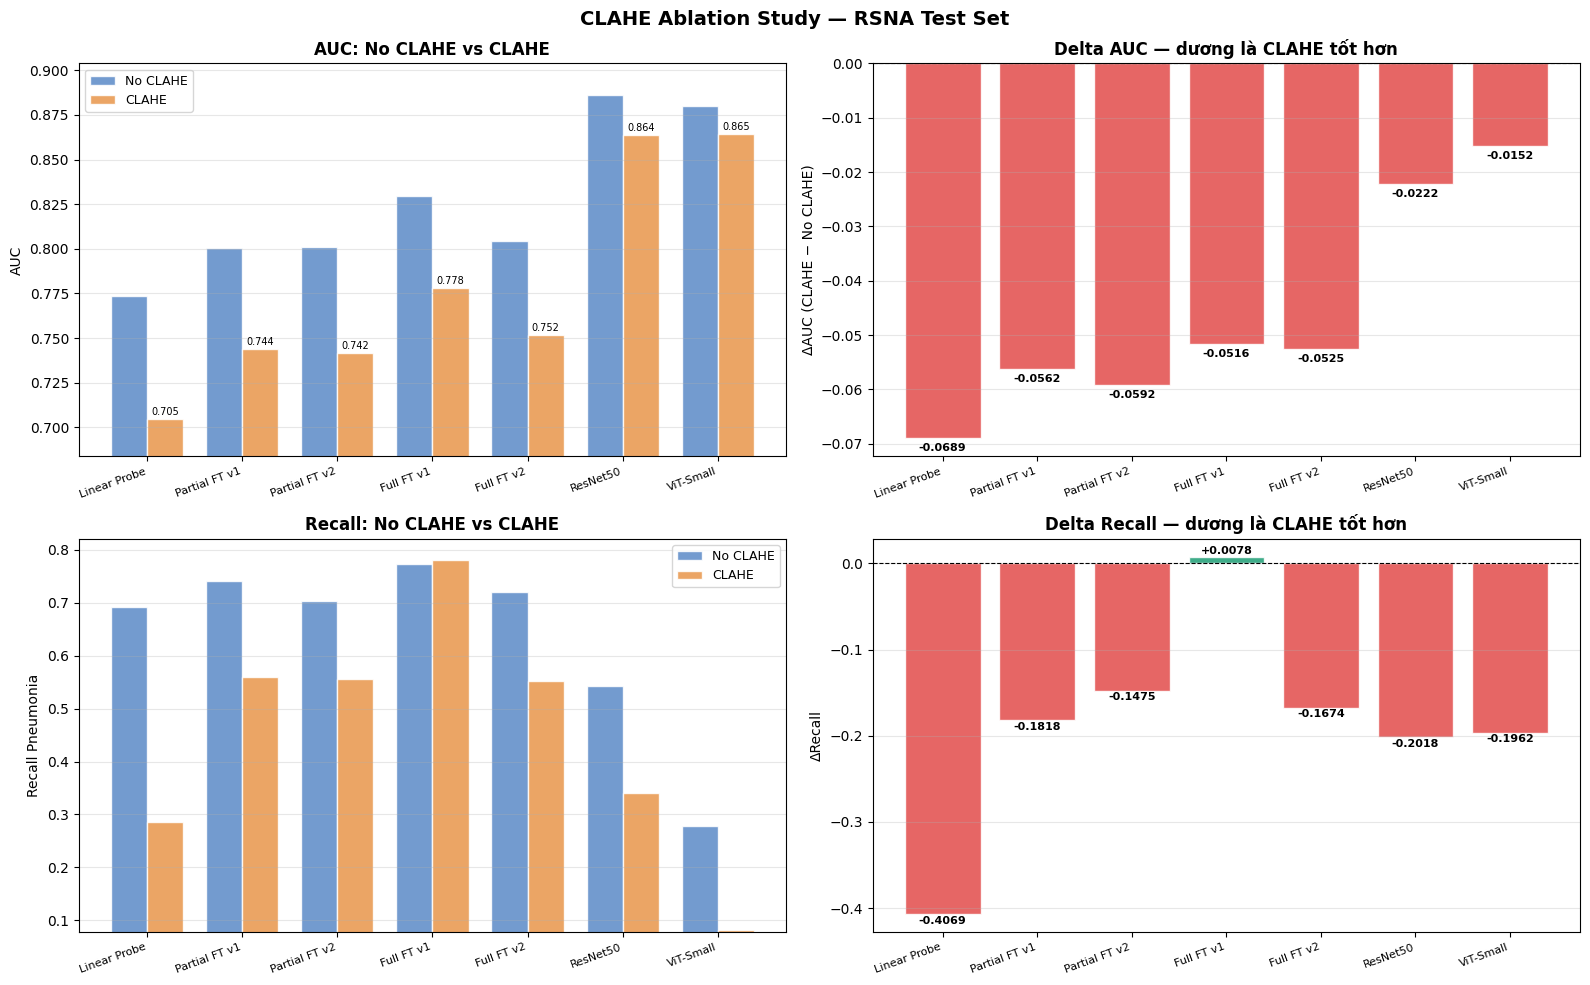

Saved: clahe_ablation.png


In [9]:
# ============================================================
# CELL 9: VISUALIZE — BAR CHART + DELTA CHART
# ============================================================
models_plot  = [r["model"] for r in rows if "delta_auc" in r]
labels_short = [m.replace("I-JEPA ","").replace(" ImageNet","") for m in models_plot]

no_clahe_auc = [results_df.loc[results_df.model==m, "no_clahe_auc"].values[0] for m in models_plot]
clahe_auc    = [results_df.loc[results_df.model==m, "clahe_auc"].values[0]    for m in models_plot]
delta_auc    = [results_df.loc[results_df.model==m, "delta_auc"].values[0]    for m in models_plot]

no_clahe_recall = [results_df.loc[results_df.model==m, "no_clahe_recall_pneumonia"].values[0] for m in models_plot]
clahe_recall    = [results_df.loc[results_df.model==m, "clahe_recall_pneumonia"].values[0]    for m in models_plot]
delta_recall    = [results_df.loc[results_df.model==m, "delta_recall"].values[0]              for m in models_plot]

x     = np.arange(len(models_plot))
width = 0.38

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("CLAHE Ablation Study — RSNA Test Set", fontsize=14, fontweight="bold", y=0.98)

# ── AUC comparison ────────────────────────────────────────
ax = axes[0,0]
b1 = ax.bar(x - width/2, no_clahe_auc, width, label="No CLAHE",
            color="#5b8ac7", alpha=0.85, edgecolor="white")
b2 = ax.bar(x + width/2, clahe_auc,    width, label="CLAHE",
            color="#e8954a", alpha=0.85, edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(labels_short, fontsize=8, rotation=20, ha="right")
ax.set_ylabel("AUC"); ax.set_title("AUC: No CLAHE vs CLAHE", fontweight="bold")
ax.set_ylim(min(no_clahe_auc + clahe_auc) * 0.97, max(no_clahe_auc + clahe_auc) * 1.02)
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
for bar, val in zip(b2, clahe_auc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f"{val:.3f}", ha="center", va="bottom", fontsize=7)

# ── Delta AUC ─────────────────────────────────────────────
ax = axes[0,1]
colors_delta = ["#1D9E75" if d >= 0 else "#E24B4A" for d in delta_auc]
bars = ax.bar(x, delta_auc, color=colors_delta, edgecolor="white", alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x); ax.set_xticklabels(labels_short, fontsize=8, rotation=20, ha="right")
ax.set_ylabel("ΔAUC (CLAHE − No CLAHE)")
ax.set_title("Delta AUC — dương là CLAHE tốt hơn", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, delta_auc):
    ypos = bar.get_height() + 0.0005 if val >= 0 else bar.get_height() - 0.001
    ax.text(bar.get_x()+bar.get_width()/2, ypos,
            f"{val:+.4f}", ha="center", va="bottom" if val >= 0 else "top",
            fontsize=8, fontweight="bold")

# ── Recall comparison ─────────────────────────────────────
ax = axes[1,0]
ax.bar(x - width/2, no_clahe_recall, width, label="No CLAHE",
       color="#5b8ac7", alpha=0.85, edgecolor="white")
ax.bar(x + width/2, clahe_recall,    width, label="CLAHE",
       color="#e8954a", alpha=0.85, edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(labels_short, fontsize=8, rotation=20, ha="right")
ax.set_ylabel("Recall Pneumonia"); ax.set_title("Recall: No CLAHE vs CLAHE", fontweight="bold")
ax.set_ylim(min(no_clahe_recall+clahe_recall)*0.95, min(1.0, max(no_clahe_recall+clahe_recall)*1.05))
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

# ── Delta Recall ──────────────────────────────────────────
ax = axes[1,1]
colors_dr = ["#1D9E75" if d >= 0 else "#E24B4A" for d in delta_recall]
bars = ax.bar(x, delta_recall, color=colors_dr, edgecolor="white", alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x); ax.set_xticklabels(labels_short, fontsize=8, rotation=20, ha="right")
ax.set_ylabel("ΔRecall")
ax.set_title("Delta Recall — dương là CLAHE tốt hơn", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, delta_recall):
    ypos = bar.get_height() + 0.001 if val >= 0 else bar.get_height() - 0.002
    ax.text(bar.get_x()+bar.get_width()/2, ypos,
            f"{val:+.4f}", ha="center", va="bottom" if val >= 0 else "top",
            fontsize=8, fontweight="bold")

plt.tight_layout()
fig.savefig(FIG_DIR/"clahe_ablation.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: clahe_ablation.png")

In [10]:
# ============================================================
# CELL 10: PHÂN TÍCH VÀ NHẬN XÉT TỰ ĐỘNG
# ============================================================
if "delta_auc" in results_df.columns:
    print("=== CLAHE IMPACT ANALYSIS ===\n")
    for _, row in results_df.iterrows():
        if "delta_auc" not in row or pd.isna(row.get("delta_auc")): continue
        d_auc    = row["delta_auc"]
        d_recall = row.get("delta_recall", 0)
        verdict  = ("✅ CẢI THIỆN" if d_auc > 0.005
                    else "❌ GIẢM"    if d_auc < -0.005
                    else "➖ KHÔNG ĐỔI")
        print(f"{row['model']:30s} | ΔAUC={d_auc:+.4f} ΔRecall={d_recall:+.4f} | {verdict}")

    print()
    delta_vals = results_df["delta_auc"].dropna()
    n_pos  = (delta_vals > 0.005).sum()
    n_neg  = (delta_vals < -0.005).sum()
    n_neut = len(delta_vals) - n_pos - n_neg
    print(f"Tổng kết: {n_pos} models cải thiện | {n_neut} không đổi | {n_neg} giảm hiệu năng")
    print(f"Mean ΔAUC: {delta_vals.mean():+.5f}")
    print(f"Best improvement: {delta_vals.max():+.4f} ({results_df.loc[delta_vals.idxmax(),'model']})")
    print(f"Worst drop:       {delta_vals.min():+.4f} ({results_df.loc[delta_vals.idxmin(),'model']})")

    if delta_vals.mean() > 0.003:
        print("\nKết luận: CLAHE có lợi nhẹ trên tập dữ liệu này.")
    elif delta_vals.mean() < -0.003:
        print("\nKết luận: CLAHE không cải thiện — model đã robust với contrast mặc định.")
    else:
        print("\nKết luận: CLAHE không tạo ra khác biệt đáng kể (|ΔAUC| < 0.003).")
    print("\nNote: Đây là valid research finding. Cả 2 kết quả đều publishable.")

=== CLAHE IMPACT ANALYSIS ===

I-JEPA Linear Probe            | ΔAUC=-0.0689 ΔRecall=-0.4069 | ❌ GIẢM
I-JEPA Partial FT v1           | ΔAUC=-0.0562 ΔRecall=-0.1818 | ❌ GIẢM
I-JEPA Partial FT v2           | ΔAUC=-0.0592 ΔRecall=-0.1475 | ❌ GIẢM
I-JEPA Full FT v1              | ΔAUC=-0.0516 ΔRecall=+0.0078 | ❌ GIẢM
I-JEPA Full FT v2              | ΔAUC=-0.0525 ΔRecall=-0.1674 | ❌ GIẢM
ResNet50 ImageNet              | ΔAUC=-0.0222 ΔRecall=-0.2018 | ❌ GIẢM
ViT-Small ImageNet             | ΔAUC=-0.0152 ΔRecall=-0.1962 | ❌ GIẢM

Tổng kết: 0 models cải thiện | 0 không đổi | 7 giảm hiệu năng
Mean ΔAUC: -0.04654
Best improvement: -0.0152 (ViT-Small ImageNet)
Worst drop:       -0.0689 (I-JEPA Linear Probe)

Kết luận: CLAHE không cải thiện — model đã robust với contrast mặc định.

Note: Đây là valid research finding. Cả 2 kết quả đều publishable.


In [11]:
# ============================================================
# CELL 11: LƯU KẾT QUẢ + NÉN OUTPUT
# ============================================================
elapsed = (time.time() - NOTEBOOK_START) / 3600
print(f"Tổng thời gian: {elapsed:.2f}h\n")

print("Files trong output:")
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print(f"  {str(p.relative_to(OUTPUT_DIR)):55s} ({p.stat().st_size/1e3:.1f} KB)")

shutil.make_archive("/kaggle/working/notebook09_clahe_ablation", "zip", OUTPUT_DIR)
print("\nCreated: notebook09_clahe_ablation.zip")

Tổng thời gian: 0.21h

Files trong output:
  figures/clahe_ablation.png                              (220.0 KB)
  i-jepa_full_ft_v1_clahe.csv                             (34.8 KB)
  i-jepa_full_ft_v1_no_clahe.csv                          (35.7 KB)
  i-jepa_full_ft_v2_clahe.csv                             (35.0 KB)
  i-jepa_linear_probe_clahe.csv                           (35.0 KB)
  i-jepa_partial_ft_v1_clahe.csv                          (34.9 KB)
  i-jepa_partial_ft_v2_clahe.csv                          (34.9 KB)
  resnet50_imagenet_clahe.csv                             (36.4 KB)
  tables/clahe_ablation_full.csv                          (1.8 KB)
  tables/clahe_ablation_summary.csv                       (0.7 KB)
  vit-small_imagenet_clahe.csv                            (38.5 KB)

Created: notebook09_clahe_ablation.zip
